In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


In [30]:

# ============================================================================
# CONFIGURATION
# ============================================================================
RESULTS_DIR = "DM_distribution_new"
ALPHA_TO_COMPARE = -4

SAVE_PLOT = False

# List of telescopes to look for
TELESCOPES = [
    "fast", 
    "parkes", 
    "meerkat_coherent", 
    "meerkat_incoherent", 
    "askap_flyeye", 
    "askap_ics",
    "dsa-110",
    "apertif"
]

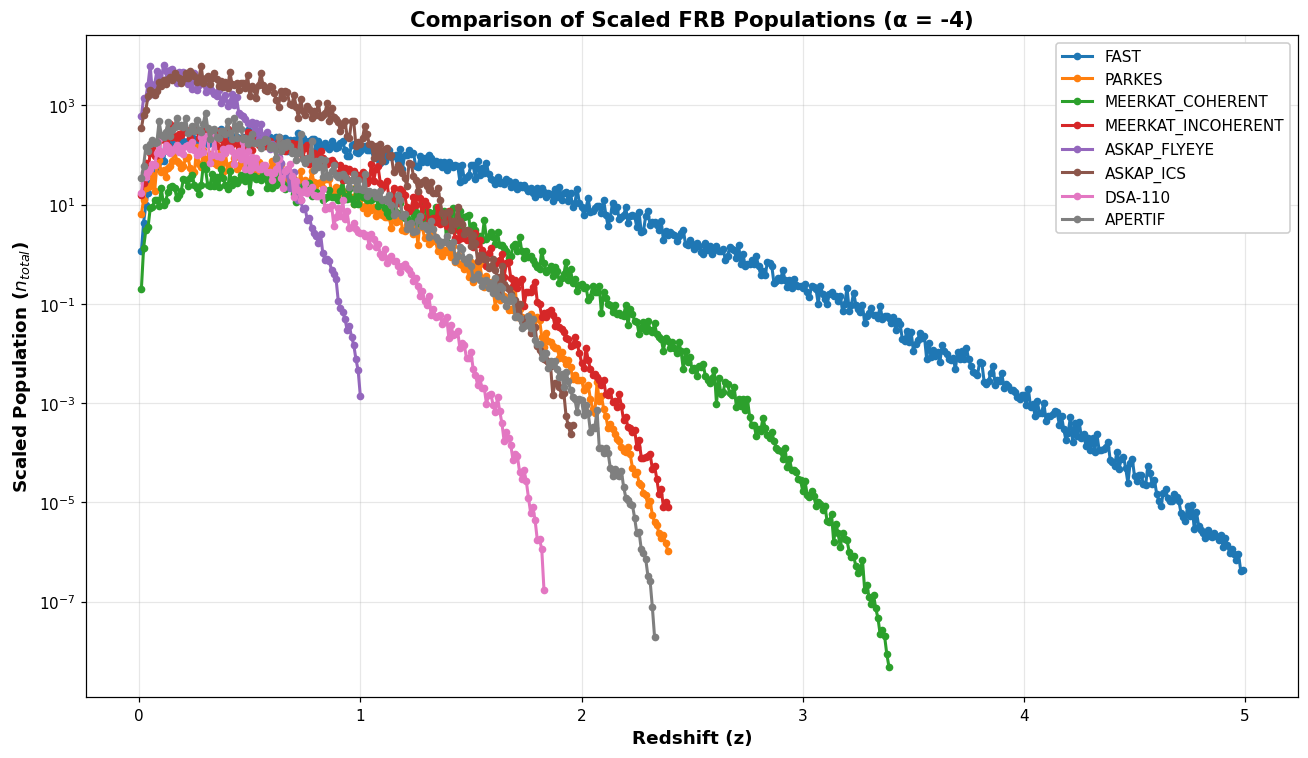


Completed comparison for 8 telescopes.


In [31]:


# ============================================================================
# LOAD AND PLOT
# ============================================================================
plt.figure(figsize=(12, 7), dpi=110)

found_files = 0
for telescope in TELESCOPES:
    # Construct filename based on telescope and alpha
    filename = f"DM_{telescope}_alpha{ALPHA_TO_COMPARE}_scaled.csv"
    filepath = os.path.join(RESULTS_DIR, filename)
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        
        # Plot Scaled Population vs Redshift
        plt.plot(df['z'], df['n_total_population_scaled'], 
                 marker='o', markersize=4, linewidth=2, label=telescope.upper())
        found_files += 1
    else:
        print(f"File not found: {filename}")

if found_files == 0:
    print(f"No results found for alpha={ALPHA_TO_COMPARE} in {RESULTS_DIR}")
else:
    # Formatting
    plt.title(f'Comparison of Scaled FRB Populations (α = {ALPHA_TO_COMPARE})', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Redshift (z)', fontsize=12, fontweight='bold')
    plt.ylabel('Scaled Population ($n_{total}$)', fontsize=12, fontweight='bold')
    
    # Use log scale for Y if the population range is very large
    plt.yscale('log')
    
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend(frameon=True, facecolor='white', framealpha=1)
    
    plt.tight_layout()
    
    if SAVE_PLOT:
        plt.savefig(f"population_comparison_alpha{ALPHA_TO_COMPARE}.png")
    
    plt.show()

print(f"\nCompleted comparison for {found_files} telescopes.")

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================================
# CONFIGURATION
# ============================================================================
RESULTS_DIR = "DM_distribution_new"

# Target redshifts to compare
TARGET_REDSHIFTS = [0.1, 0.3, 0.5, 1.0, 2.0, 4.0]

# List of telescopes to look for
TELESCOPES = [
    "fast", 
    "parkes", 
    "meerkat_coherent", 
    "meerkat_incoherent", 
    "askap_flyeye", 
    "askap_ics",
    "dsa-110"
]

# ============================================================================
# LOAD DATA FOR ALL TELESCOPES
# ============================================================================
data_dict = {}
for telescope in TELESCOPES:
    filename = f"DM_{telescope}_alpha{ALPHA_TO_COMPARE}_scaled.csv"
    filepath = os.path.join(RESULTS_DIR, filename)
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        data_dict[telescope] = df
        print(f"✓ Loaded {telescope}")
    else:
        print(f"✗ Not found: {filename}")


✓ Loaded fast
✓ Loaded parkes
✓ Loaded meerkat_coherent
✓ Loaded meerkat_incoherent
✓ Loaded askap_flyeye
✓ Loaded askap_ics
✓ Loaded dsa-110


fast                : DM range [   10.0,  4990.0] pc/cm³ | Total pop:    23348.3
parkes              : DM range [   10.0,  2390.0] pc/cm³ | Total pop:     5115.6
meerkat_coherent    : DM range [   10.0,  3390.0] pc/cm³ | Total pop:     2826.1
meerkat_incoherent  : DM range [   10.0,  2390.0] pc/cm³ | Total pop:    17214.5
askap_flyeye        : DM range [   10.0,  1000.0] pc/cm³ | Total pop:   133524.3
askap_ics           : DM range [   10.0,  1960.0] pc/cm³ | Total pop:   210470.3
dsa-110             : DM range [   10.0,  1830.0] pc/cm³ | Total pop:     7344.6


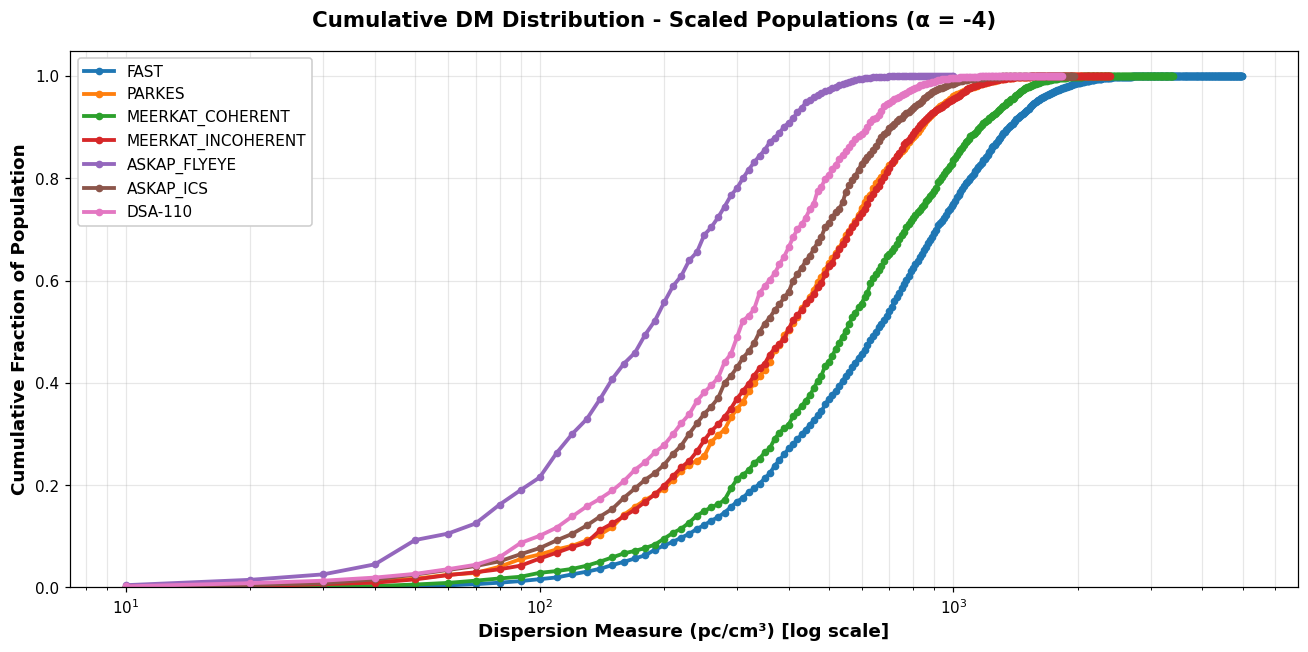


DM STATISTICS SUMMARY
         Telescope  N_Bins DM_min DM_max Total_Population
              FAST     499   10.0 4990.0          23348.3
            PARKES     239   10.0 2390.0           5115.6
  MEERKAT_COHERENT     339   10.0 3390.0           2826.1
MEERKAT_INCOHERENT     239   10.0 2390.0          17214.5
      ASKAP_FLYEYE     100   10.0 1000.0         133524.3
         ASKAP_ICS     196   10.0 1960.0         210470.3
           DSA-110     183   10.0 1830.0           7344.6


In [33]:
# ============================================================================
# CUMULATIVE DM DISTRIBUTION FROM SCALED POPULATIONS
# ============================================================================

# ============================================================================
# LOAD DATA FOR ALL TELESCOPES (if not already loaded)
# ============================================================================
if 'data_dict' not in locals():
    data_dict = {}
    for telescope in TELESCOPES:
        filename = f"DM_{telescope}_alpha{ALPHA_TO_COMPARE}_scaled.csv"
        filepath = os.path.join(RESULTS_DIR, filename)
        
        if os.path.exists(filepath):
            df = pd.read_csv(filepath)
            data_dict[telescope] = df
            print(f"✓ Loaded {telescope}")
        else:
            print(f"✗ Not found: {filename}")

# ============================================================================
# CONVERT REDSHIFTS TO DM AND CREATE CUMULATIVE DISTRIBUTIONS
# ============================================================================
cumulative_data = {}

for telescope, df in data_dict.items():
    # Convert redshift to DM: DM = z * 1000 pc/cm³
    dm_values = df['z'].values * 1000
    dm_values = np.sort(dm_values)
    
    # Get corresponding scaled populations
    pop_values = df['n_total_population_scaled'].values
    
    # Calculate cumulative distribution (normalized by total population)
    cumulative_pop = np.cumsum(pop_values[np.argsort(df['z'].values)])
    cumulative_fraction = cumulative_pop / cumulative_pop[-1]
    
    cumulative_data[telescope] = {
        'dm': dm_values,
        'cumulative': cumulative_fraction,
        'n_bins': len(dm_values),
        'dm_min': dm_values.min(),
        'dm_max': dm_values.max(),
        'pop_total': pop_values.sum()
    }
    
    print(f"{telescope:20s}: DM range [{dm_values.min():7.1f}, {dm_values.max():7.1f}] pc/cm³ | "
          f"Total pop: {pop_values.sum():10.1f}")

# ============================================================================
# VISUALIZATION: CUMULATIVE DM DISTRIBUTION (LOG SCALE)
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6), dpi=110)

# Add main title
fig.suptitle(f'Cumulative DM Distribution - Scaled Populations (α = {ALPHA_TO_COMPARE})', 
             fontsize=14, fontweight='bold')

# Log scale for DM
for telescope, data in cumulative_data.items():
    ax.semilogx(data['dm'], data['cumulative'], marker='o', markersize=4,
                linewidth=2.5, label=f"{telescope.upper()}")

ax.set_xlabel('Dispersion Measure (pc/cm³) [log scale]', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Fraction of Population', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')
ax.legend(frameon=True, facecolor='white', framealpha=1, loc='best')
ax.set_ylim([0, 1.05])

plt.tight_layout()
if SAVE_PLOT:
    plt.savefig(f"DM_cumulative_scaled_population_alpha{ALPHA_TO_COMPARE}.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# STATISTICS TABLE
# ============================================================================
print("\n" + "="*100)
print("DM STATISTICS SUMMARY")
print("="*100)

stats_data = []
for telescope in TELESCOPES:
    if telescope in cumulative_data:
        data = cumulative_data[telescope]
        stats_data.append({
            'Telescope': telescope.upper(),
            'N_Bins': data['n_bins'],
            'DM_min': f"{data['dm_min']:.1f}",
            'DM_max': f"{data['dm_max']:.1f}",
            'Total_Population': f"{data['pop_total']:.1f}"
        })

df_stats = pd.DataFrame(stats_data)
print(df_stats.to_string(index=False))
print("="*100)

In [34]:

# ============================================================================
# CREATE COMPARISON TABLE AT TARGET REDSHIFTS
# ============================================================================
comparison_data = []

for target_z in TARGET_REDSHIFTS:
    row = {'z': target_z}
    for telescope, df in data_dict.items():
        # Find closest redshift
        idx = (df['z'] - target_z).abs().argmin()
        closest_z = df['z'].iloc[idx]
        pop = df['n_total_population_scaled'].iloc[idx]
        row[telescope] = pop
        row[f'{telescope}_z_actual'] = closest_z
    
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)

# Display the table (extract just population values)
print("\n" + "="*100)
print("SCALED POPULATION COMPARISON AT TARGET REDSHIFTS")
print("="*100)

# Create clean display table
display_dict = {}
for target_z in TARGET_REDSHIFTS:
    display_dict[target_z] = {}
    row_data = df_comparison[df_comparison['z'] == target_z].iloc[0]
    for telescope in TELESCOPES:
        if telescope in data_dict:
            display_dict[target_z][telescope] = row_data[telescope]

display_df = pd.DataFrame(display_dict).T
print(display_df.to_string())



SCALED POPULATION COMPARISON AT TARGET REDSHIFTS
           fast     parkes  meerkat_coherent  meerkat_incoherent  askap_flyeye    askap_ics       dsa-110
0.1   89.961741  44.759938      2.165801e+01          239.045370   3293.601256  2486.983047  1.022518e+02
0.3  251.330028  83.437072      5.108276e+01          332.180064   1899.459554  3476.277106  2.410519e+02
0.5  254.168088  62.715028      1.799646e+01          272.098206    422.231800  1544.324211  5.033330e+01
1.0  121.964998  13.240097      1.752071e+01           36.441715      0.001356   166.861225  2.729748e+00
2.0    8.805300   0.002961      2.453908e-01            0.006491      0.001356     0.000363  1.736190e-07
4.0    0.001471   0.000001      4.765191e-09            0.000008      0.001356     0.000363  1.736190e-07


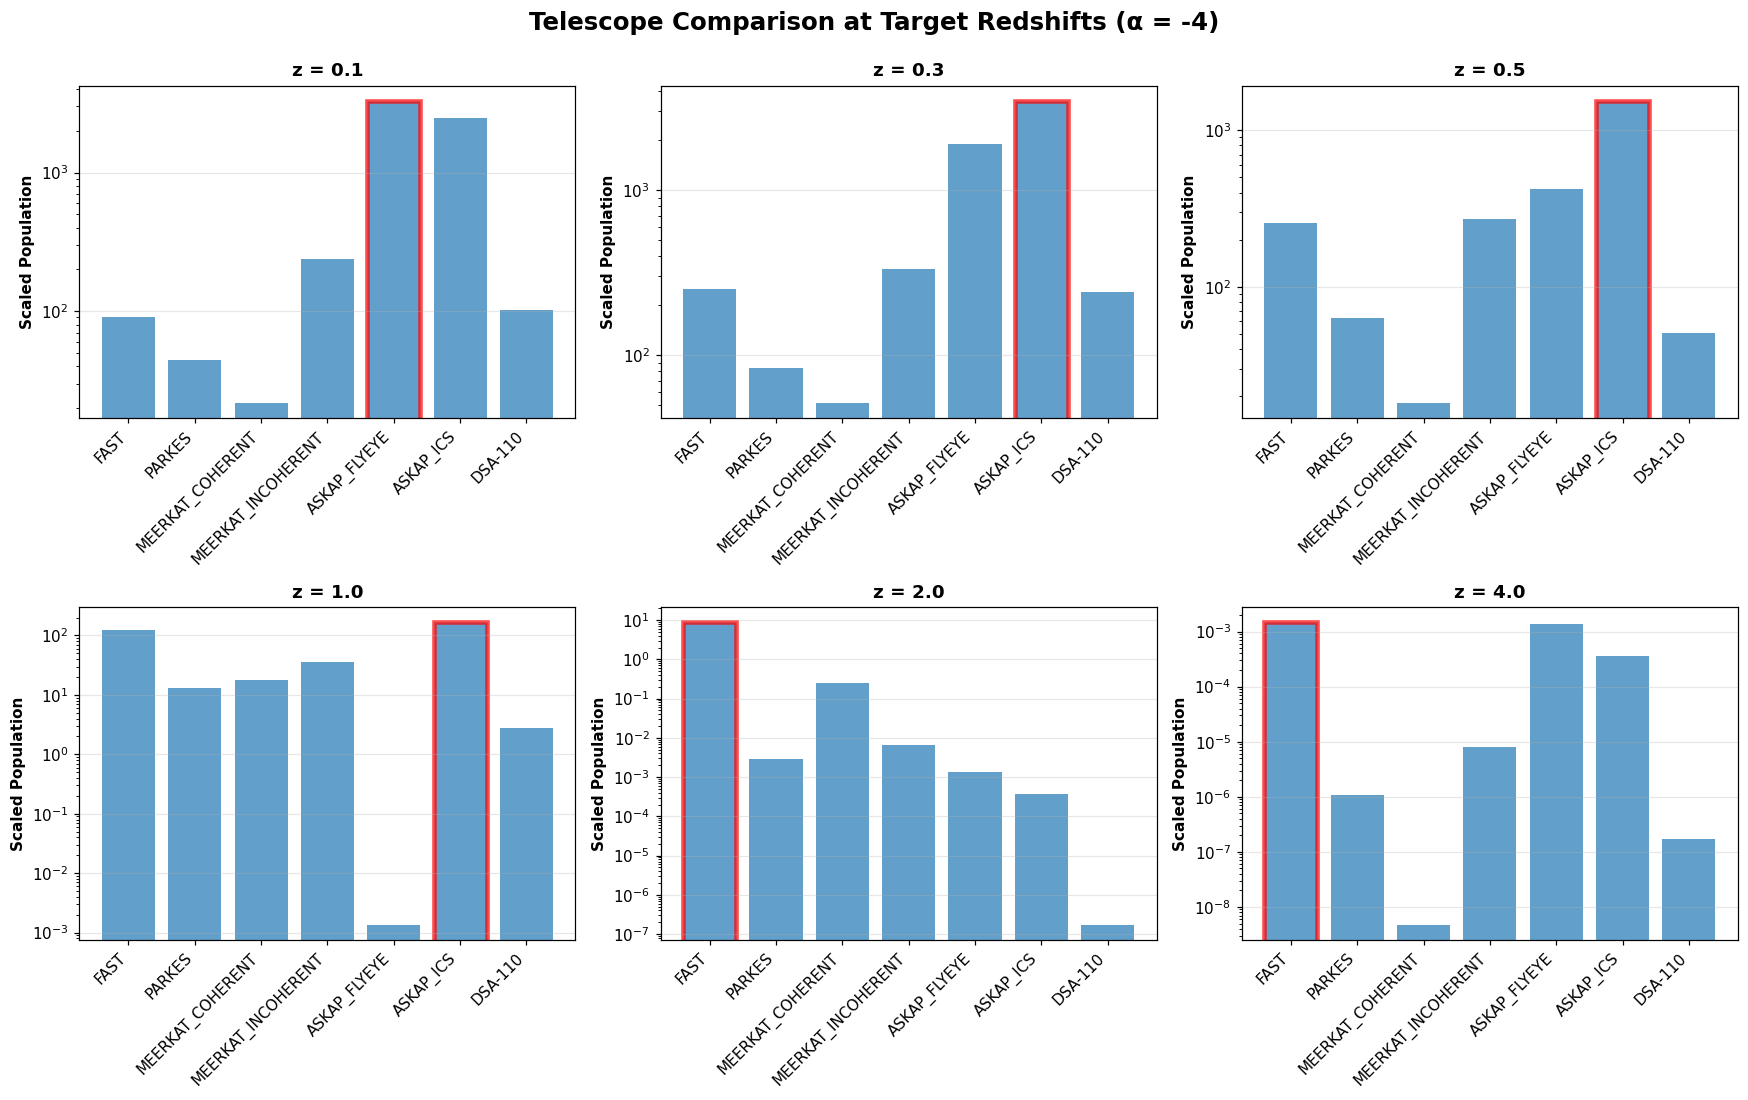


TELESCOPE RANKING AT EACH REDSHIFT (1=Best)
  z                     1                      2                          3                        4                  5               6                       7
0.1 ASKAP_FLYEYE (3293.6)     ASKAP_ICS (2487.0) MEERKAT_INCOHERENT (239.0)          DSA-110 (102.3)        FAST (90.0)   PARKES (44.8) MEERKAT_COHERENT (21.7)
0.3    ASKAP_ICS (3476.3)  ASKAP_FLYEYE (1899.5) MEERKAT_INCOHERENT (332.2)             FAST (251.3)    DSA-110 (241.1)   PARKES (83.4) MEERKAT_COHERENT (51.1)
0.5    ASKAP_ICS (1544.3)   ASKAP_FLYEYE (422.2) MEERKAT_INCOHERENT (272.1)             FAST (254.2)      PARKES (62.7)  DSA-110 (50.3) MEERKAT_COHERENT (18.0)
1.0     ASKAP_ICS (166.9)           FAST (122.0)  MEERKAT_INCOHERENT (36.4)  MEERKAT_COHERENT (17.5)      PARKES (13.2)   DSA-110 (2.7)      ASKAP_FLYEYE (0.0)
2.0            FAST (8.8) MEERKAT_COHERENT (0.2)   MEERKAT_INCOHERENT (0.0)             PARKES (0.0) ASKAP_FLYEYE (0.0) ASKAP_ICS (0.0)           DSA-110 (

In [ ]:

# ============================================================================
# BAR CHART COMPARISON AT EACH REDSHIFT (SINGLE COLOR FOR ALL BARS)
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=110)
axes = axes.flatten()

# Add main title with alpha value at the top
fig.suptitle(f'Telescope Comparison at Target Redshifts (α = {ALPHA_TO_COMPARE})', 
             fontsize=16, fontweight='bold', y=0.995)

# Single color for all bars
bar_color = 'tab:blue'  # Nice blue color

for idx, target_z in enumerate(TARGET_REDSHIFTS):
    ax = axes[idx]
    
    # Get populations for this redshift
    populations = []
    labels = []
    for telescope in TELESCOPES:
        if telescope in data_dict:
            row_data = df_comparison[df_comparison['z'] == target_z].iloc[0]
            populations.append(row_data[telescope])
            labels.append(telescope.upper())
    
    # Bar chart with same color for all bars
    bars = ax.bar(range(len(labels)), populations, color=bar_color, alpha = 0.7)
    
    # Find and highlight the best telescope
    best_idx = np.argmax(populations)
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(3)
    
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Scaled Population', fontweight='bold')
    ax.set_title(f'z = {target_z}', fontweight='bold', fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_yscale('log')

plt.tight_layout()
# plt.savefig(f"population_comparison_specific_z_alpha{ALPHA_TO_COMPARE}.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# RANKING TABLE
# ============================================================================
print("\n" + "="*100)
print("TELESCOPE RANKING AT EACH REDSHIFT (1=Best)")
print("="*100)

ranking_data = []
for target_z in TARGET_REDSHIFTS:
    row = {'z': target_z}
    row_data = df_comparison[df_comparison['z'] == target_z].iloc[0]
    
    # Sort telescopes by population
    pop_dict = {tel: row_data[tel] for tel in TELESCOPES if tel in data_dict}
    sorted_tel = sorted(pop_dict.items(), key=lambda x: x[1], reverse=True)
    
    for rank, (tel, pop) in enumerate(sorted_tel, 1):
        row[f'{rank}'] = f"{tel.upper()} ({pop:.1f})"
    
    ranking_data.append(row)

df_ranking = pd.DataFrame(ranking_data)
print(df_ranking.to_string(index=False))